# Memorization vs Learning in Fluoroquinolone Resistance Prediction

Analysis showing how non-singleton approaches achieve misleading performance through memorization rather than biological understanding.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics 
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

## Part 1: Non-singleton approach with duplicates

In [51]:
# Load data with all duplicate mutations
data = pd.read_csv('data/ML_DATA_MXF.csv')
data.dropna(inplace=True)

print("Total samples with duplicates:", len(data))
print("Unique mutations:", data.GENE_MUTATION.nunique())
print("Average samples per mutation:", len(data)/data.GENE_MUTATION.nunique())

data.CLEAN_BINARY_PHENOTYPE.value_counts()

Total samples with duplicates: 1644
Unique mutations: 145
Average samples per mutation: 11.337931034482759


CLEAN_BINARY_PHENOTYPE
R    1380
S     264
Name: count, dtype: int64

In [52]:
# Check mutation-phenotype consistency
mutation_consistency = data.groupby('GENE_MUTATION')['CLEAN_BINARY_PHENOTYPE'].nunique()
consistent_mutations = sum(mutation_consistency == 1)
inconsistent_mutations = sum(mutation_consistency > 1)

print("Mutations with consistent phenotype:", consistent_mutations)
print("Mutations with inconsistent phenotype:", inconsistent_mutations)
print("Consistency rate:", consistent_mutations / len(mutation_consistency))

if inconsistent_mutations == 0:
    print("Perfect consistency - pure memorization possible!")

Mutations with consistent phenotype: 145
Mutations with inconsistent phenotype: 0
Consistency rate: 1.0
Perfect consistency - pure memorization possible!


In [53]:
# Prepare features and labels
features_MXF = ['d_volume', 'd_MW', 'd_Pi', 'secondary_structure', 'psi',
                'n_hbond_acceptors', 'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor']

true_label = data.CLEAN_BINARY_PHENOTYPE
features = data[features_MXF].copy()
features['secondary_structure_codes'] = pd.Categorical(features.secondary_structure, 
                                                      categories=features.secondary_structure.unique()).codes
features.drop('secondary_structure', inplace=True, axis=1)

replacement = {"R": 1, "S": 0}
y = true_label.replace(replacement)

random_seed = 144
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.30, random_state=random_seed)

In [54]:
# Train models on non-singleton data
logreg = LogisticRegression(solver='newton-cg', random_state=random_seed, 
                           class_weight='balanced', C=0.001, penalty='l2')
logreg.fit(X_train, y_train)

# these are the optimised parameters
xgb = XGBClassifier(n_estimators=150, subsample=0.6, max_depth=4, 
                   min_child_weight=1, learning_rate=0.125, random_state=random_seed)
xgb.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

print("Logistic Regression accuracy:", metrics.accuracy_score(y_test, y_pred_lr))
print("XGBoost accuracy:", metrics.accuracy_score(y_test, y_pred_xgb))

# Calculate sensitivity and specificity for non-singleton approach
cnf_matrix_lr = metrics.confusion_matrix(y_test, y_pred_lr)
cnf_matrix_xgb = metrics.confusion_matrix(y_test, y_pred_xgb)

if cnf_matrix_lr.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_lr.ravel()
    sensitivity_lr = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_lr = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"LR Sensitivity (resistance detection): {sensitivity_lr:.3f}")
    print(f"LR Specificity (susceptible detection): {specificity_lr:.3f}")

if cnf_matrix_xgb.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_xgb.ravel()
    sensitivity_xgb = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_xgb = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"XGB Sensitivity (resistance detection): {sensitivity_xgb:.3f}")
    print(f"XGB Specificity (susceptible detection): {specificity_xgb:.3f}")

Logistic Regression accuracy: 0.9777327935222672
XGBoost accuracy: 0.9939271255060729
LR Sensitivity (resistance detection): 0.974
LR Specificity (susceptible detection): 1.000
XGB Sensitivity (resistance detection): 0.993
XGB Specificity (susceptible detection): 1.000


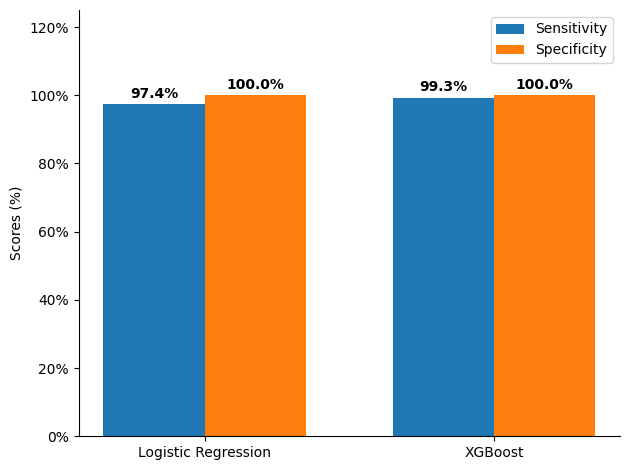

In [55]:
#Plot sensitivity and specificity of both models
labels = ['Logistic Regression', 'XGBoost']
sensitivity = [sensitivity_lr, sensitivity_xgb]
specificity = [specificity_lr, specificity_xgb] 
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, sensitivity, width, label='Sensitivity', color='tab:blue')
rects2 = ax.bar(x + width/2, specificity, width, label='Specificity', color='tab:orange')
ax.set_ylabel('Scores (%)')
# ax.set_title('Sensitivity and Specificity by Model (Non-Singleton Data)')
ax.set_xticks(x)
#remove frame on top and right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels(labels)
ax.legend()

# Format bar labels as percentages
for rect in rects1:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontweight='bold')

for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.01,
            f'{height*100:.1f}%', ha='center', va='bottom', fontweight='bold')

# Format y-axis as percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))

fig.tight_layout()
plt.ylim(0, 1.25)
plt.show()  

/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_57544/3115961431.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


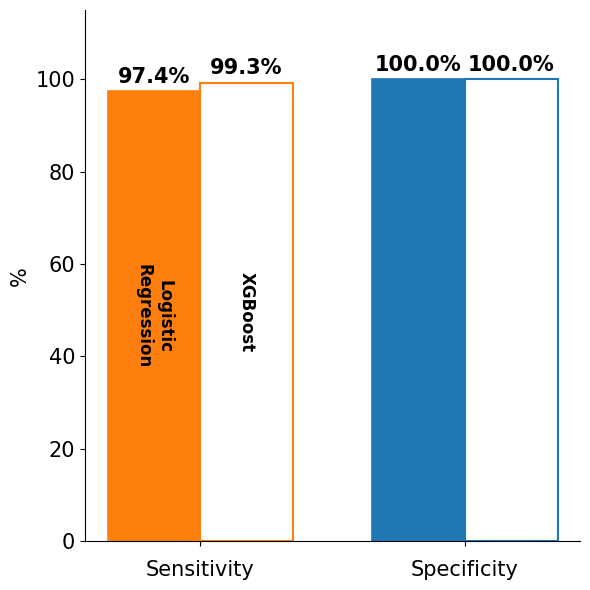

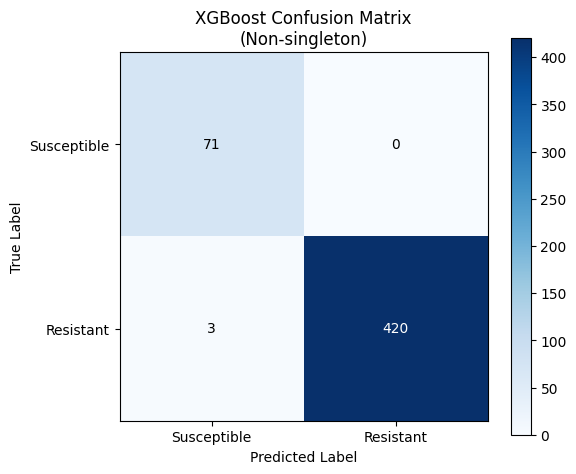

In [62]:
# Plot sensitivity and specificity with enhanced styling (matching reference plot style)
x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
bar_width = 0.35

fig, ax = plt.subplots(figsize=(6, 6))

# Colors matching your original plot but with the professional styling
blue = '#1f77b4'    # Sensitivity (tab:blue equivalent)
orange = '#ff7f0e'  # Specificity (tab:orange equivalent)

# Bar values for both models
lr_values = [sensitivity_lr, specificity_lr]  # Logistic Regression
xgb_values = [sensitivity_xgb, specificity_xgb]  # XGBoost

# Create bars with filled and hollow styling
bars_lr = ax.bar(x_pos - bar_width/2, lr_values, width=bar_width,
                 color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2)

bars_xgb = ax.bar(x_pos + bar_width/2, xgb_values, width=bar_width,
                  color='white', edgecolor=[orange, blue], linewidth=1.5)

# Add percentage labels above bars
for bar, val in zip(list(bars_lr) + list(bars_xgb), lr_values + xgb_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val * 100:.1f}%', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Add model labels inside bars (rotated)
model_labels_lr = ['Logistic\nRegression', '']
model_labels_xgb = ['XGBoost', '']

for i in range(2):  # 0 = sensitivity, 1 = specificity
    if model_labels_lr[i]:
        bar = bars_lr[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_lr[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')
    if model_labels_xgb[i]:
        bar = bars_xgb[i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                model_labels_xgb[i], ha='center', va='center', rotation=270,
                fontsize=12, color='black', fontweight='bold')

# Set labels and styling
ax.set_xticks(x_pos)
ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
ax.xaxis.set_tick_params(pad=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('%', fontsize=15)

# Format y-axis as percentages
yticks = ax.get_yticks()
ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)

# Clean styling - remove top and right spines
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', labelsize=15)

plt.tight_layout()
plt.show()

# Keep the confusion matrix visualization
fig, ax2 = plt.subplots(figsize=(6, 5))
cm = cnf_matrix_xgb
im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax2.figure.colorbar(im, ax=ax2)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax2.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')
ax2.set_title('XGBoost Confusion Matrix\n(Non-singleton)')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Susceptible', 'Resistant'])
ax2.set_yticklabels(['Susceptible', 'Resistant'])

plt.tight_layout()
plt.show()

In [57]:
# check out the 3 misclassified resistant samples in XGBoost
misclassified_indices = X_test[(y_test == 1) & (y_pred_xgb == 0)].index
misclassified_samples = data.loc[misclassified_indices]
print("Misclassified resistant samples:\n", misclassified_samples)

Misclassified resistant samples:
       index DRUG  MIC  LOG2MIC BINARY_PHENOTYPE PHENOTYPE_QUALITY  GENE  \
1021   1021  MXF  4.0      2.0                R              HIGH  gyrA   
1090   1090  MXF   >4      3.0                R              HIGH  gyrB   
456     456  MXF  2.0      1.0                R              HIGH  gyrA   

      POSITION GENE_MUTATION CLEAN_BINARY_PHENOTYPE  ...      T       SASA  \
1021     288.0    gyrA_A288D                      R  ...  False  11.676534   
1090     446.0    gyrB_R446L                      R  ...  False  48.145591   
456      105.0    gyrA_L105R                      R  ...   True   8.473817   

     snap2_score  snap2_accuracy   dist_MGB   dist_MGE  dist_drug  \
1021        -6.0            53.0  42.918834  29.384776  31.706489   
1090        23.0            63.0  29.518379  35.925126  29.680615   
456         67.0            80.0  29.083642  20.283453  26.567283   

      temp_factor     depth deep_ddG  
1021    85.980003  1.984847   -2.547

In [58]:
# check if these 3 misclassified samples have mutations that were not in the training set
train_mutations = set(data.loc[X_train.index, 'GENE_MUTATION'])
test_mutations = set(data.loc[X_test.index, 'GENE_MUTATION'])
misclassified_mutations = set(misclassified_samples['GENE_MUTATION'])
unseen_mutations = misclassified_mutations - train_mutations
print("Unseen mutations in misclassified samples:", unseen_mutations)
print("Out of", len(misclassified_mutations), "misclassified mutations,",len(unseen_mutations),"are not present in the training set.")

Unseen mutations in misclassified samples: {'gyrA_A288D', 'gyrA_L105R'}
Out of 3 misclassified mutations, 2 are not present in the training set.


## Part 2: Data leakage analysis

In [59]:
# Check for data leakage - same mutations in train and test
train_mutations = set(data.loc[X_train.index, 'GENE_MUTATION'])
test_mutations = set(data.loc[X_test.index, 'GENE_MUTATION'])

overlapping_mutations = train_mutations & test_mutations
novel_mutations = test_mutations - train_mutations

print("Mutations in training:", len(train_mutations))
print("Mutations in test:", len(test_mutations))
print("Overlapping mutations:", len(overlapping_mutations))
print("Novel mutations in test:", len(novel_mutations))
print("Overlap ratio:", len(overlapping_mutations) / len(test_mutations))

print("\nData leakage detected - same mutations in train and test!")

Mutations in training: 117
Mutations in test: 65
Overlapping mutations: 37
Novel mutations in test: 28
Overlap ratio: 0.5692307692307692

Data leakage detected - same mutations in train and test!


Performance on SEEN mutations (memorization):
LR accuracy: 0.9805194805194806
XGB accuracy: 0.9978354978354979
LR Sensitivity on seen: 0.979, Specificity: 1.000
XGB Sensitivity on seen: 0.998, Specificity: 1.000

Performance on NOVEL mutations:
LR accuracy: 0.9375
XGB accuracy: 0.9375
Novel mutations count: 32
LR Sensitivity on novel: 0.000, Specificity: 1.000
XGB Sensitivity on novel: 0.000, Specificity: 1.000

High performance even on novel mutations - suspicious!
Could be gene-level memorization or class imbalance


/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_57544/3549299934.py:128: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)


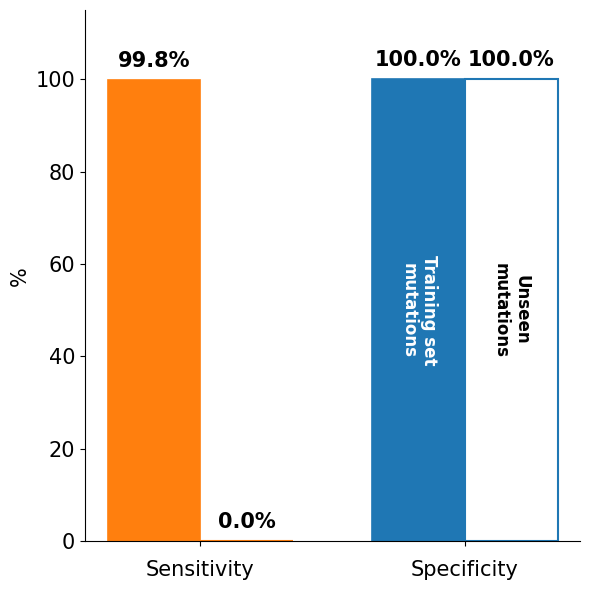


XGBoost Memorization Effect Summary:
Seen mutations (memorization):
  - Sensitivity: 99.8%
  - Specificity: 100.0%
Novel mutations (generalization):
  - Sensitivity: 0.0%
  - Specificity: 100.0%
Performance drops:
  - Sensitivity drop: 99.8%
  - Specificity drop: 0.0%


In [66]:
# Performance on seen vs novel mutations
test_data = data.loc[X_test.index]
overlap_mask = test_data.GENE_MUTATION.isin(overlapping_mutations)
novel_mask = test_data.GENE_MUTATION.isin(novel_mutations)

overlap_acc_lr = metrics.accuracy_score(y_test[overlap_mask], y_pred_lr[overlap_mask])
overlap_acc_xgb = metrics.accuracy_score(y_test[overlap_mask], y_pred_xgb[overlap_mask])

print("Performance on SEEN mutations (memorization):")
print("LR accuracy:", overlap_acc_lr)
print("XGB accuracy:", overlap_acc_xgb)

# Calculate sensitivity/specificity for seen mutations
if sum(overlap_mask) > 0:
    cnf_overlap_lr = metrics.confusion_matrix(y_test[overlap_mask], y_pred_lr[overlap_mask])
    cnf_overlap_xgb = metrics.confusion_matrix(y_test[overlap_mask], y_pred_xgb[overlap_mask])
    
    if cnf_overlap_lr.shape == (2, 2):
        tn, fp, fn, tp = cnf_overlap_lr.ravel()
        sens_lr = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_lr = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"LR Sensitivity on seen: {sens_lr:.3f}, Specificity: {spec_lr:.3f}")
    
    if cnf_overlap_xgb.shape == (2, 2):
        tn, fp, fn, tp = cnf_overlap_xgb.ravel()
        sens_xgb = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_xgb = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"XGB Sensitivity on seen: {sens_xgb:.3f}, Specificity: {spec_xgb:.3f}")

if len(novel_mutations) > 0:
    novel_acc_lr = metrics.accuracy_score(y_test[novel_mask], y_pred_lr[novel_mask])
    novel_acc_xgb = metrics.accuracy_score(y_test[novel_mask], y_pred_xgb[novel_mask])
    
    print("\nPerformance on NOVEL mutations:")
    print("LR accuracy:", novel_acc_lr)
    print("XGB accuracy:", novel_acc_xgb)
    print("Novel mutations count:", sum(novel_mask))
    
    # Calculate sensitivity/specificity for novel mutations
    if sum(novel_mask) > 0:
        cnf_novel_lr = metrics.confusion_matrix(y_test[novel_mask], y_pred_lr[novel_mask])
        cnf_novel_xgb = metrics.confusion_matrix(y_test[novel_mask], y_pred_xgb[novel_mask])
        
        if cnf_novel_lr.shape == (2, 2):
            tn, fp, fn, tp = cnf_novel_lr.ravel()
            sens_lr = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_lr = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"LR Sensitivity on novel: {sens_lr:.3f}, Specificity: {spec_lr:.3f}")
        
        if cnf_novel_xgb.shape == (2, 2):
            tn, fp, fn, tp = cnf_novel_xgb.ravel()
            sens_xgb = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_xgb = tn / (tn + fp) if (tn + fp) > 0 else 0
            print(f"XGB Sensitivity on novel: {sens_xgb:.3f}, Specificity: {spec_xgb:.3f}")
    
    print("\nHigh performance even on novel mutations - suspicious!")
    print("Could be gene-level memorization or class imbalance")

# Plot XGBoost sensitivity and specificity on seen vs novel mutations (combined)
if len(novel_mutations) > 0:
    # Create single plot combining sensitivity and specificity
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Colors for sensitivity and specificity
    blue = '#1f77b4'    # Sensitivity
    orange = '#ff7f0e'  # Specificity
    
    # Check if we have data for both seen and novel mutations
    if sum(overlap_mask) > 0 and sum(novel_mask) > 0:
        # Get sensitivity and specificity values for XGBoost only
        if cnf_overlap_xgb.shape == (2, 2) and cnf_novel_xgb.shape == (2, 2):
            # Sensitivity for seen mutations
            tn, fp, fn, tp = cnf_overlap_xgb.ravel()
            sens_xgb_seen = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_xgb_seen = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            # Sensitivity for novel mutations
            tn, fp, fn, tp = cnf_novel_xgb.ravel()
            sens_xgb_novel = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_xgb_novel = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            # Set up bar positions
            x_pos = np.arange(2)  # 0 = Sensitivity, 1 = Specificity
            bar_width = 0.35
            
            # Values for seen and novel mutations
            seen_values = [sens_xgb_seen, spec_xgb_seen]
            novel_values = [sens_xgb_novel, spec_xgb_novel]
            
            # Create bars - filled for seen (training set), hollow for novel (unseen)
            bars_seen = ax.bar(x_pos - bar_width/2, seen_values, width=bar_width,
                             color=[orange, blue], edgecolor=[orange, blue], linewidth=1.2)
            
            bars_novel = ax.bar(x_pos + bar_width/2, novel_values, width=bar_width,
                              color='white', edgecolor=[orange, blue], linewidth=1.5)
            
            # Add percentage labels above bars
            for bar, val in zip(list(bars_seen) + list(bars_novel), seen_values + novel_values):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                       f'{val * 100:.1f}%', ha='center', va='bottom', 
                       fontsize=15, fontweight='bold')
            
            # Add mutation type labels inside bars
            mutation_labels_seen = ['', 'Training set\nmutations']
            mutation_labels_novel = ['', 'Unseen\nmutations']
            
            for i in range(2):  # 0 = sensitivity, 1 = specificity
                if mutation_labels_seen[i] and seen_values[i] > 0.15:
                    bar = bars_seen[i]
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                           mutation_labels_seen[i], ha='center', va='center', rotation=270,
                           fontsize=12, color='white', fontweight='bold')
                if mutation_labels_novel[i] and novel_values[i] > 0.15:
                    bar = bars_novel[i]
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                           mutation_labels_novel[i], ha='center', va='center', rotation=270,
                           fontsize=12, color='black', fontweight='bold')
            
            # Set labels and styling
            ax.set_xticks(x_pos)
            ax.set_xticklabels(['Sensitivity', 'Specificity'], fontsize=15)
            ax.xaxis.set_tick_params(pad=10)
            ax.set_ylim(0, 1.15)
            ax.set_ylabel('%', fontsize=15)
            
            # Format y-axis as percentages
            yticks = ax.get_yticks()
            ax.set_yticklabels([f'{int(t * 100)}' for t in yticks], fontsize=15)
            
            # Clean styling - remove top and right spines
            ax.spines[['right', 'top']].set_visible(False)
            ax.tick_params(axis='both', labelsize=15)
            
        else:
            ax.text(0.5, 0.5, 'Insufficient data for\ncomparison', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
    else:
        ax.text(0.5, 0.5, 'No novel mutations\nfor comparison', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary of memorization effect (XGBoost only, sensitivity and specificity)
    if sum(overlap_mask) > 0 and sum(novel_mask) > 0 and cnf_overlap_xgb.shape == (2, 2) and cnf_novel_xgb.shape == (2, 2):
        print(f"\nXGBoost Memorization Effect Summary:")
        print(f"===================================")
        print(f"Seen mutations (memorization):")
        print(f"  - Sensitivity: {sens_xgb_seen:.1%}")
        print(f"  - Specificity: {spec_xgb_seen:.1%}")
        print(f"Novel mutations (generalization):")
        print(f"  - Sensitivity: {sens_xgb_novel:.1%}")
        print(f"  - Specificity: {spec_xgb_novel:.1%}")
        print(f"Performance drops:")
        print(f"  - Sensitivity drop: {(sens_xgb_seen - sens_xgb_novel):.1%}")
        print(f"  - Specificity drop: {(spec_xgb_seen - spec_xgb_novel):.1%}")
else:
    print("No novel mutations found for comparison.")

## Part 3: Testing with singleton approach

In [67]:
# Create singleton dataset - one sample per mutation
data_singleton = data.drop_duplicates(subset=['GENE_MUTATION'], keep='first')

print("Singleton samples:", len(data_singleton))
print("Original samples:", len(data))
print("Reduction factor:", len(data) / len(data_singleton))

singleton_counts = data_singleton.CLEAN_BINARY_PHENOTYPE.value_counts()
print("\nSingleton class distribution:")
print(singleton_counts)
print("Resistance rate:", singleton_counts['R'] / len(data_singleton))

Singleton samples: 145
Original samples: 1644
Reduction factor: 11.337931034482759

Singleton class distribution:
CLEAN_BINARY_PHENOTYPE
S    126
R     19
Name: count, dtype: int64
Resistance rate: 0.1310344827586207


In [68]:
# Prepare singleton features
true_label_singleton = data_singleton.CLEAN_BINARY_PHENOTYPE
features_singleton = data_singleton[features_MXF].copy()
features_singleton['secondary_structure_codes'] = pd.Categorical(
    features_singleton.secondary_structure, 
    categories=features_singleton.secondary_structure.unique()).codes
features_singleton.drop('secondary_structure', inplace=True, axis=1)

y_singleton = true_label_singleton.replace(replacement)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    features_singleton, y_singleton, test_size=0.30, random_state=random_seed)

print("Singleton train set:", len(X_train_s))
print("Singleton test set:", len(X_test_s))
print("Test resistant:", sum(y_test_s == 1))
print("Test susceptible:", sum(y_test_s == 0))

Singleton train set: 101
Singleton test set: 44
Test resistant: 4
Test susceptible: 40


In [69]:
# Train models on singleton data
logreg_s = LogisticRegression(solver='newton-cg', random_state=random_seed, 
                             class_weight='balanced', C=0.001, penalty='l2')
logreg_s.fit(X_train_s, y_train_s)

xgb_s = XGBClassifier(n_estimators=150, subsample=0.6, max_depth=4, 
                     min_child_weight=1, learning_rate=0.125, random_state=random_seed)
xgb_s.fit(X_train_s, y_train_s)

y_pred_lr_s = logreg_s.predict(X_test_s)
y_pred_xgb_s = xgb_s.predict(X_test_s)

print("Singleton Logistic Regression accuracy:", metrics.accuracy_score(y_test_s, y_pred_lr_s))
print("Singleton XGBoost accuracy:", metrics.accuracy_score(y_test_s, y_pred_xgb_s))

Singleton Logistic Regression accuracy: 0.8636363636363636
Singleton XGBoost accuracy: 0.9545454545454546


In [70]:
# Detailed performance analysis
cnf_matrix_lr_s = metrics.confusion_matrix(y_test_s, y_pred_lr_s)
cnf_matrix_xgb_s = metrics.confusion_matrix(y_test_s, y_pred_xgb_s)

print("Singleton LR confusion matrix:")
print(cnf_matrix_lr_s)

print("\nSingleton XGB confusion matrix:")
print(cnf_matrix_xgb_s)

if cnf_matrix_lr_s.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_lr_s.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\nLR Sensitivity (resistance detection): {sensitivity:.3f}")
    print(f"LR Specificity (susceptible detection): {specificity:.3f}")

if cnf_matrix_xgb_s.shape == (2, 2):
    tn, fp, fn, tp = cnf_matrix_xgb_s.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"\nXGB Sensitivity (resistance detection): {sensitivity:.3f}")
    print(f"XGB Specificity (susceptible detection): {specificity:.3f}")

Singleton LR confusion matrix:
[[35  5]
 [ 1  3]]

Singleton XGB confusion matrix:
[[40  0]
 [ 2  2]]

LR Sensitivity (resistance detection): 0.750
LR Specificity (susceptible detection): 0.875

XGB Sensitivity (resistance detection): 0.500
XGB Specificity (susceptible detection): 1.000


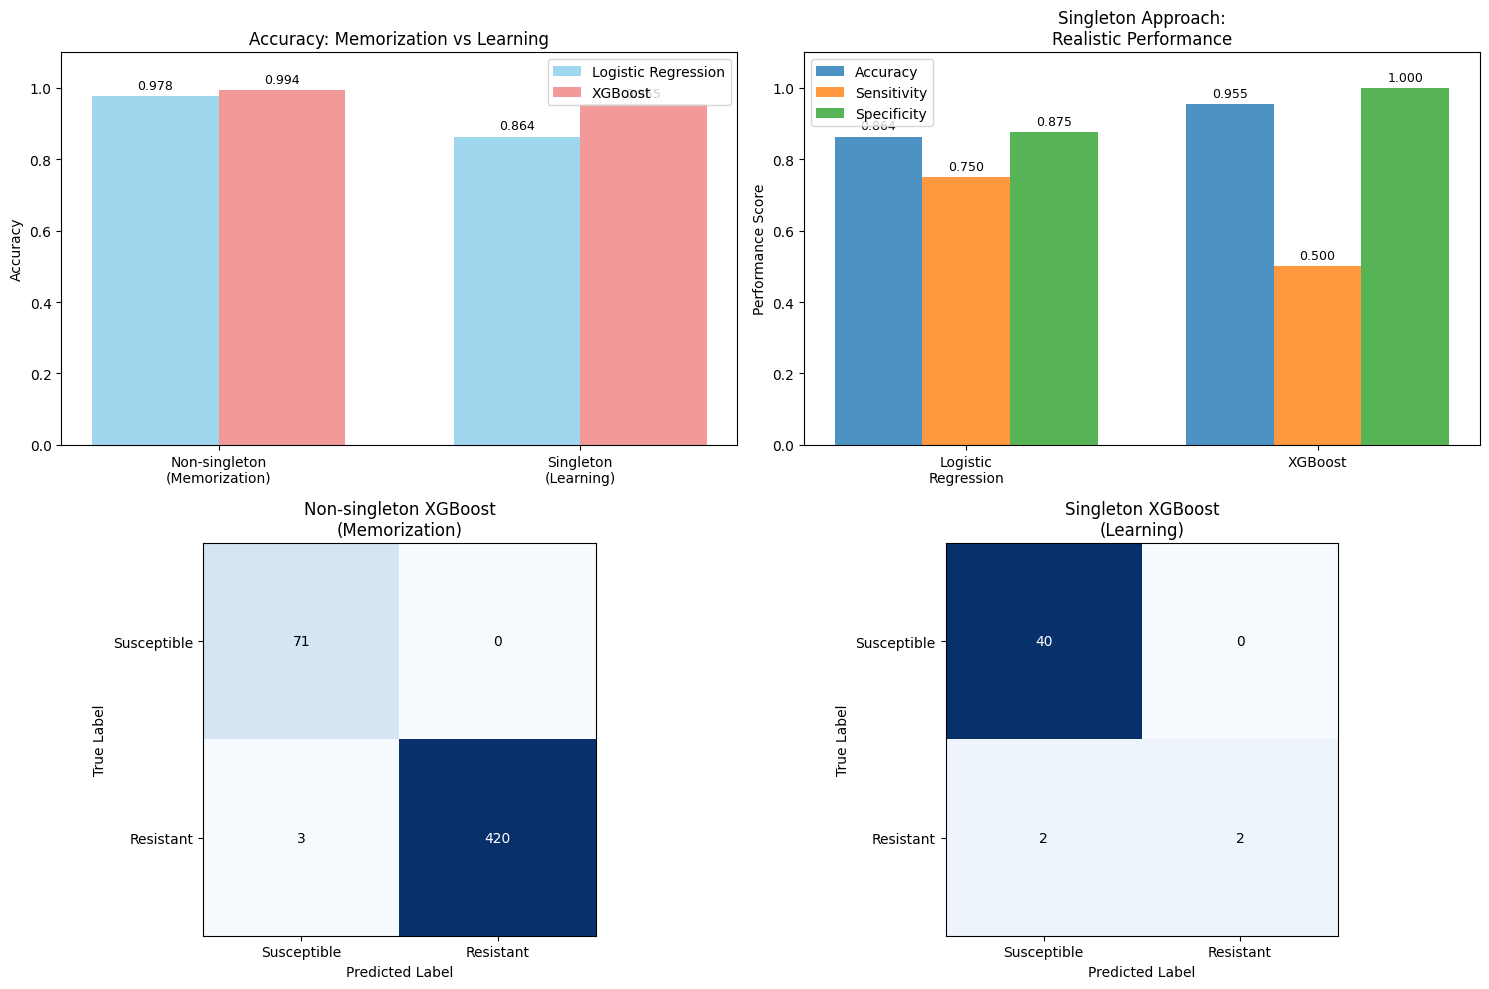

Performance degradation from memorization to learning:
XGBoost accuracy drop: 0.994 → 0.955
Sample size reduction: 1644 → 145 (8.8% retained)
This reveals the true difficulty of structure-based resistance prediction


In [71]:
# Visualize singleton approach performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Overall performance comparison between approaches
approaches = ['Non-singleton\n(Memorization)', 'Singleton\n(Learning)']
models = ['LR', 'XGB']

# Accuracy comparison
lr_acc_comp = [metrics.accuracy_score(y_test, y_pred_lr), metrics.accuracy_score(y_test_s, y_pred_lr_s)]
xgb_acc_comp = [metrics.accuracy_score(y_test, y_pred_xgb), metrics.accuracy_score(y_test_s, y_pred_xgb_s)]

x = np.arange(len(approaches))
width = 0.35

bars1 = ax1.bar(x - width/2, lr_acc_comp, width, label='Logistic Regression', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, xgb_acc_comp, width, label='XGBoost', alpha=0.8, color='lightcoral')

ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy: Memorization vs Learning')
ax1.set_xticks(x)
ax1.set_xticklabels(approaches)
ax1.legend()
ax1.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Singleton approach detailed metrics
models_single = ['Logistic\nRegression', 'XGBoost']
singleton_acc = [metrics.accuracy_score(y_test_s, y_pred_lr_s), metrics.accuracy_score(y_test_s, y_pred_xgb_s)]

# Calculate singleton sensitivity and specificity
singleton_sens = []
singleton_spec = []

for cm in [cnf_matrix_lr_s, cnf_matrix_xgb_s]:
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        singleton_sens.append(sens)
        singleton_spec.append(spec)
    else:
        singleton_sens.append(0)
        singleton_spec.append(0)

x_single = np.arange(len(models_single))
width_single = 0.25

bars1 = ax2.bar(x_single - width_single, singleton_acc, width_single, label='Accuracy', alpha=0.8)
bars2 = ax2.bar(x_single, singleton_sens, width_single, label='Sensitivity', alpha=0.8)
bars3 = ax2.bar(x_single + width_single, singleton_spec, width_single, label='Specificity', alpha=0.8)

ax2.set_ylabel('Performance Score')
ax2.set_title('Singleton Approach:\nRealistic Performance')
ax2.set_xticks(x_single)
ax2.set_xticklabels(models_single)
ax2.legend()
ax2.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Confusion matrices comparison
cms = [cnf_matrix_xgb, cnf_matrix_xgb_s]
titles = ['Non-singleton XGBoost\n(Memorization)', 'Singleton XGBoost\n(Learning)']
axes = [ax3, ax4]

for cm, title, ax in zip(cms, titles, axes):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black")
    
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Susceptible', 'Resistant'])
    ax.set_yticklabels(['Susceptible', 'Resistant'])

plt.tight_layout()
plt.show()

print("Performance degradation from memorization to learning:")
print("====================================================")
print(f"XGBoost accuracy drop: {metrics.accuracy_score(y_test, y_pred_xgb):.3f} → {metrics.accuracy_score(y_test_s, y_pred_xgb_s):.3f}")
print(f"Sample size reduction: {len(data)} → {len(data_singleton)} ({len(data_singleton)/len(data):.1%} retained)")
print(f"This reveals the true difficulty of structure-based resistance prediction")

## Part 4: Comparison and conclusions

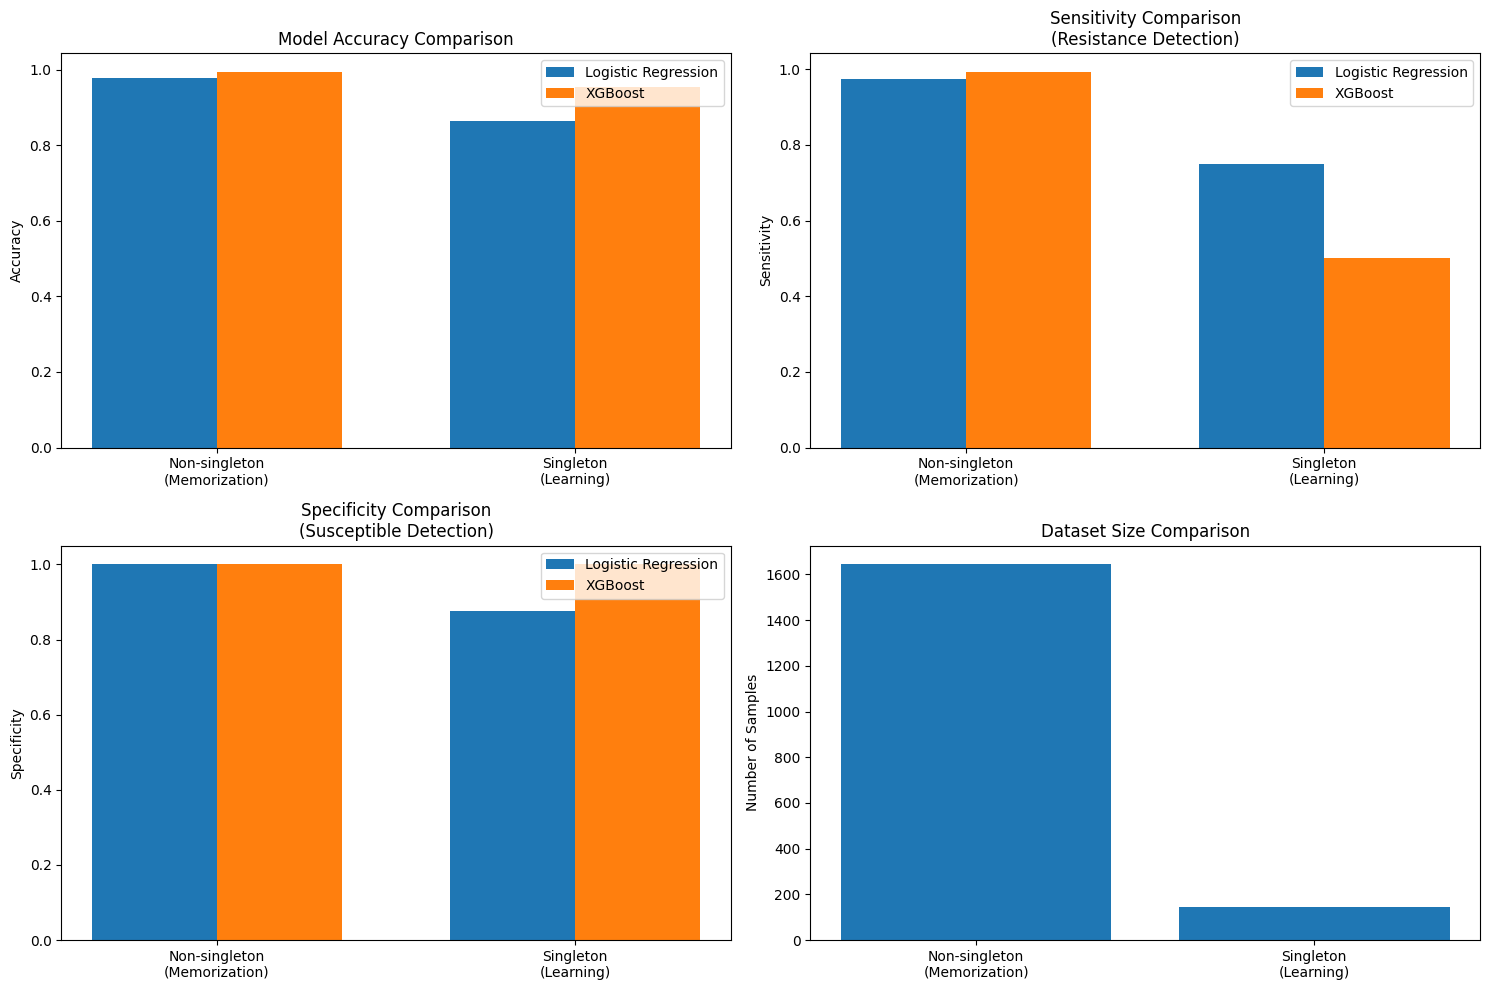

In [72]:
# Compare performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Performance comparison - Accuracy
approaches = ['Non-singleton\n(Memorization)', 'Singleton\n(Learning)']
lr_scores = [metrics.accuracy_score(y_test, y_pred_lr), metrics.accuracy_score(y_test_s, y_pred_lr_s)]
xgb_scores = [metrics.accuracy_score(y_test, y_pred_xgb), metrics.accuracy_score(y_test_s, y_pred_xgb_s)]

x = np.arange(len(approaches))
width = 0.35

ax1.bar(x - width/2, lr_scores, width, label='Logistic Regression')
ax1.bar(x + width/2, xgb_scores, width, label='XGBoost')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(approaches)
ax1.legend()

# Sensitivity comparison
lr_sens = [sensitivity_lr, cnf_matrix_lr_s.ravel()[3] / (cnf_matrix_lr_s.ravel()[3] + cnf_matrix_lr_s.ravel()[2]) if cnf_matrix_lr_s.shape == (2, 2) else 0]
xgb_sens = [sensitivity_xgb, cnf_matrix_xgb_s.ravel()[3] / (cnf_matrix_xgb_s.ravel()[3] + cnf_matrix_xgb_s.ravel()[2]) if cnf_matrix_xgb_s.shape == (2, 2) else 0]

ax2.bar(x - width/2, lr_sens, width, label='Logistic Regression')
ax2.bar(x + width/2, xgb_sens, width, label='XGBoost')
ax2.set_ylabel('Sensitivity')
ax2.set_title('Sensitivity Comparison\n(Resistance Detection)')
ax2.set_xticks(x)
ax2.set_xticklabels(approaches)
ax2.legend()

# Specificity comparison
lr_spec = [specificity_lr, cnf_matrix_lr_s.ravel()[0] / (cnf_matrix_lr_s.ravel()[0] + cnf_matrix_lr_s.ravel()[1]) if cnf_matrix_lr_s.shape == (2, 2) else 0]
xgb_spec = [specificity_xgb, cnf_matrix_xgb_s.ravel()[0] / (cnf_matrix_xgb_s.ravel()[0] + cnf_matrix_xgb_s.ravel()[1]) if cnf_matrix_xgb_s.shape == (2, 2) else 0]

ax3.bar(x - width/2, lr_spec, width, label='Logistic Regression')
ax3.bar(x + width/2, xgb_spec, width, label='XGBoost')
ax3.set_ylabel('Specificity')
ax3.set_title('Specificity Comparison\n(Susceptible Detection)')
ax3.set_xticks(x)
ax3.set_xticklabels(approaches)
ax3.legend()

# Sample size comparison
sample_sizes = [len(data), len(data_singleton)]
ax4.bar(approaches, sample_sizes)
ax4.set_ylabel('Number of Samples')
ax4.set_title('Dataset Size Comparison')

plt.tight_layout()
plt.show()

In [73]:
# Performance summary table
summary_data = {
    'Approach': ['Non-singleton (LR)', 'Non-singleton (XGB)', 'Singleton (LR)', 'Singleton (XGB)'],
    'Accuracy': [
        metrics.accuracy_score(y_test, y_pred_lr),
        metrics.accuracy_score(y_test, y_pred_xgb),
        metrics.accuracy_score(y_test_s, y_pred_lr_s),
        metrics.accuracy_score(y_test_s, y_pred_xgb_s)
    ],
    'Sensitivity': [
        sensitivity_lr,
        sensitivity_xgb,
        cnf_matrix_lr_s.ravel()[3] / (cnf_matrix_lr_s.ravel()[3] + cnf_matrix_lr_s.ravel()[2]) if cnf_matrix_lr_s.shape == (2, 2) else 0,
        cnf_matrix_xgb_s.ravel()[3] / (cnf_matrix_xgb_s.ravel()[3] + cnf_matrix_xgb_s.ravel()[2]) if cnf_matrix_xgb_s.shape == (2, 2) else 0
    ],
    'Specificity': [
        specificity_lr,
        specificity_xgb,
        cnf_matrix_lr_s.ravel()[0] / (cnf_matrix_lr_s.ravel()[0] + cnf_matrix_lr_s.ravel()[1]) if cnf_matrix_lr_s.shape == (2, 2) else 0,
        cnf_matrix_xgb_s.ravel()[0] / (cnf_matrix_xgb_s.ravel()[0] + cnf_matrix_xgb_s.ravel()[1]) if cnf_matrix_xgb_s.shape == (2, 2) else 0
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(3)

print("Performance Summary:")
print("==================")
print(summary_df.to_string(index=False))

print(f"\nKey observations:")
print(f"• Non-singleton approaches show artificially high performance across all metrics")
print(f"• Singleton approaches reveal more realistic (modest) performance")
print(f"• Large performance gap demonstrates memorization vs learning effect")

Performance Summary:
           Approach  Accuracy  Sensitivity  Specificity
 Non-singleton (LR)     0.978        0.974        1.000
Non-singleton (XGB)     0.994        0.993        1.000
     Singleton (LR)     0.864        0.750        0.875
    Singleton (XGB)     0.955        0.500        1.000

Key observations:
• Non-singleton approaches show artificially high performance across all metrics
• Singleton approaches reveal more realistic (modest) performance
• Large performance gap demonstrates memorization vs learning effect


In [74]:
# Final analysis
print("Key findings:")
print(f"1. Non-singleton approach: {len(overlapping_mutations)/len(test_mutations):.1%} data leakage")
print(f"2. Perfect mutation-phenotype consistency enables memorization")
print(f"3. High performance on 'novel' mutations due to gene-level patterns")
print(f"4. Singleton approach reveals true difficulty: only {singleton_counts['R']} resistant mutations")
print(f"5. Modest singleton performance reflects biological complexity")

print("\nConclusion:")
print("For FQ resistance in TB, we lack sufficient biological understanding")
print("and diverse resistance mutation data for reliable structure-based prediction.")
print("Non-singleton approaches create false optimism through memorization.")

Key findings:
1. Non-singleton approach: 56.9% data leakage
2. Perfect mutation-phenotype consistency enables memorization
3. High performance on 'novel' mutations due to gene-level patterns
4. Singleton approach reveals true difficulty: only 19 resistant mutations
5. Modest singleton performance reflects biological complexity

Conclusion:
For FQ resistance in TB, we lack sufficient biological understanding
and diverse resistance mutation data for reliable structure-based prediction.
Non-singleton approaches create false optimism through memorization.
